In [1]:
import pandas as pd
import numpy as np
from final_project.data import read_data
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from collections import OrderedDict
from torch.utils.data import DataLoader, TensorDataset
import scipy.stats as stats
import itertools
import copy


/opt/homebrew/Caskroom/miniconda/base/envs/final-project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [2]:
df = read_data("btc_with_gbt_preds")
df.head()

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,-0.004551,0.179834,0.276626,0.260862,0.320585,0.412672,0.208573,-0.042709,NONE,9.886201e-08


Note that data is pre-split into train/val/test, and we already have predictions from my best GBT model. Plenty of preprocessing has already been done.

### Part 2: Mixed Density Network
Now, I will construct a feature set and training/validation pipeline to create the best MDN to predict future distributions of returns.

In [3]:
df_train = df.query("split == 'train'")

In [4]:
def downsample(df: pd.DataFrame, minutes: set[int]) -> pd.DataFrame:
    """
    Return dataframe with datapoints from specified minutes within each hour.
    """
    return df[df["minute"].isin(minutes)]

def add_past_returns(df: pd.DataFrame, windows: list[int], log: bool = False) -> pd.DataFrame:
    """
    Return dataframe with past returns computed for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"] / df["open"].shift(window) - 1
        df[f"past_{window}m_{'log_' if log else ''}ret"] = np.log(1 + ret) if log else ret
    return df

def add_past_sq_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past returns computed for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"] / df["open"].shift(window) - 1
        df[f"past_{window}m_sq_ret"] = ret ** 2
    return df

def add_future_sq_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with future returns computed for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"].shift(-window) / df["open"] - 1
        df[f"future_{window}m_sq_ret"] = ret ** 2
    return df

def add_future_mean_sq_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past mean 1m sq returns for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    ret = df["open"] / df["open"].shift(1) - 1
    df["past_1m_sq_ret"] = ret ** 2
    
    for window in windows:
        df[f"future_{window}m_mean_sq_ret"] = df["past_1m_sq_ret"].rolling(window).mean().shift(-window)
    
    return df

def add_past_mean_sq_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past mean 1m sq returns for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    ret = df["open"] / df["open"].shift(1) - 1
    df["past_1m_sq_ret"] = ret ** 2
    
    for window in windows:
        df[f"past_{window}m_mean_sq_ret"] = df["past_1m_sq_ret"].rolling(window).mean()
    
    return df

def add_normalized_past_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past returns normalized by mean 1m sq returns over that period.
    for each window. Assumes data is every minute.
    """
    df = df.copy()
    df = add_past_returns(df, windows=windows)
    df = add_past_mean_sq_returns(df, windows=windows)
    for window in windows:
        df[f"past_{window}m_norm_ret"] = df[f"past_{window}m_ret"] / np.sqrt(df[f"past_{window}m_mean_sq_ret"] * window)
    return df

def add_future_returns(df: pd.DataFrame, windows: list[int], log: bool = False) -> pd.DataFrame:
    """
    Return dataframe with future returns for each window. Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"].shift(-window) / df["open"] - 1
        df[f"future_{window}m_{'log_' if log else ''}ret"] = np.log(1 + ret) if log else ret
    return df

def add_future_mean_abs_returns(df: pd.DataFrame, windows: list[int], log: bool = False) -> pd.DataFrame:
    """
    Return dataframe with future returns for each window. Assumes data is every minute.
    """
    df = df.copy()
    df["past_1m_abs_ret"] = np.abs(df["open"] / df["open"].shift(1) - 1)
    for window in windows:
        df[f"future_{window}m_mean_abs_ret"] = df["past_1m_abs_ret"].rolling(window).mean().shift(-window)
    return df


def add_lagged_feature(df: pd.DataFrame, col: str, max_lag: int) -> pd.DataFrame:
    """
    Return dataframe with past returns normalized by mean 1m sq returns over that period.
    for each window. Assumes data is every minute.
    """
    df = df.copy()
    for lag in range(1, max_lag + 1):
        new_col = f"{col}_lag_{lag}"
        df[new_col] = df[col].shift(lag)
    return df

def add_neutral_up_down_label(df: pd.DataFrame, threshold: float, window: int) -> pd.DataFrame:
    """
    Return dataframe with past returns normalized by mean 1m sq returns over that period.
    for each window. Assumes data is every minute.
    """
    df = df.copy()
    df = add_future_returns(df, [window])
    df[f"future_{window}m_neutral_up_down"] = np.where(df[f"future_{window}m_ret"] > threshold, 2, np.where(df[f"future_{window}m_ret"] < -threshold, 0, 1))
    return df

In [5]:
df = add_future_returns(df, [30])
df = add_past_returns(df, [1, 5, 30, 60, 120])
df = add_past_sq_returns(df, [1, 5, 30, 60, 120])
df = add_future_mean_abs_returns(df, [30])
df = add_future_mean_sq_returns(df, [5, 15, 30])
df = add_neutral_up_down_label(df, 0.001, 30)

In [6]:
NUM_FEATURES = [
    "past_1m_ret",
    "past_5m_ret",
    "past_30m_ret",
    "past_60m_ret",
    "past_120m_ret",
    "past_1m_sq_ret",
    "past_5m_sq_ret",
    "past_30m_sq_ret",
    "past_60m_sq_ret",
    "past_120m_sq_ret",
    "past_1440m_vol",
    "past_10080m_vol",
    "past_43200m_vol",
    "past_50m_span_ewm_vol",
    "past_50m_vol_pct_change",
    "past_30m_quote_volume",
    "past_30m_trades",
    "quote_volume_pct_change",
    "is_us_trading_day",
    "is_eu_trading_day",
    "is_uk_trading_day",
    "is_jp_trading_day",
    "is_cn_trading_day",
    "is_hk_trading_day",
    "is_us_dst",
    "is_eu_dst",
    "gbt_future_30m_mean_sq_ret_pred"
]

CAT_FEATURES = ["time_of_day", "event_code"]

TARGET_COL = "future_30m_ret"




df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna()
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()

# Make numerical feature tensors
X_train_num = df_train[NUM_FEATURES].to_numpy(dtype=np.float32)
X_val_num = df_val[NUM_FEATURES].to_numpy(dtype=np.float32)
y_train = df_train[TARGET_COL].to_numpy(dtype=np.float32)
y_val = df_val[TARGET_COL].to_numpy(dtype=np.float32)

# Scale features, train scaler on train set
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)

# Make categorical feature tensors
X_train_cat = df_train[CAT_FEATURES]
X_val_cat = df_val[CAT_FEATURES]

# Encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
X_train_cat = encoder.fit_transform(X_train_cat)
X_val_cat = encoder.transform(X_val_cat)

X_train_cat = torch.tensor(X_train_cat, dtype=torch.float32)
X_val_cat = torch.tensor(X_val_cat, dtype=torch.float32)

X_train = torch.cat([X_train_num, X_train_cat], dim=1)
X_val = torch.cat([X_val_num, X_val_cat], dim=1)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)




device = "cuda" if torch.cuda.is_available() else "cpu"



First model: hidden layers directly to output layer for mixed density parameters.

In [7]:
# Create MDN

class MDN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, n_components=3, mean_zero=False,
                 dropout=0):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i}", nn.ReLU()))
            hidden_layer_list.append((f"dropout{i}", nn.Dropout(dropout)))


        self.net = nn.Sequential(OrderedDict([
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu_input", nn.ReLU()),
            ("dropout_input", nn.Dropout(dropout))] + hidden_layer_list
        ))

        self.mixture_weights = nn.Linear(hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.net(x)

        mixture_weights = self.mixture_weights(out)

        if self.means is not None:
            uncentered_means = self.means(out)
            means = uncentered_means - torch.mean(uncentered_means)
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_weights, means, scales


def compute_nll_from_output(y, mixture_weights, means, scales, lambda_mean = 0.0):
    y = y.unsqueeze(1)

    log_probs = (
        -0.5 * np.log(2 * np.pi)
        - torch.log(scales)
        - 0.5 * ((y - means) / scales) ** 2
    )

    log_mix = F.log_softmax(mixture_weights, dim=1)
    log_density = torch.logsumexp(log_mix + log_probs, dim=1)

    return -log_density.mean() + lambda_mean * torch.mean(torch.sum(log_mix * means ** 2, dim=1))

def compute_nll(model, data_loader, lambda_mean = 0.0):
    model.eval() 
    size = 0
    nll_sum = 0
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
            mixture_weights, means, scales = model(X)

            nll = compute_nll_from_output(y, mixture_weights, means, scales, lambda_mean=lambda_mean)
            nll_sum += nll * X.size(0)
            size += X.size(0)

    return nll_sum / size

def crps_helper(a, scale):
    """
    Closed form function used for gaussian mixture CRPS.
    """
    value = 2 * scale * stats.norm.pdf(a / scale) +  a * (2 * stats.norm.cdf(a / scale) - 1)
    return value

def compute_crps(model, data_loader):
    """
    Compute mean crps using MDN and data loader.
    """
    model.eval() 
    all_crps = []
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
            mixture_weights, means, scales = model(X)
            mixture_probs = F.softmax(mixture_weights, dim=1)

            a_one = y.unsqueeze(1) - means
            scale_one = scales
            weights_one = mixture_probs
            first_term_raw = crps_helper(a_one, scale_one)
            first_term = torch.sum(first_term_raw * weights_one, dim=1)
            
            a_two = means.unsqueeze(2) - means.unsqueeze(1)
            scale_two = torch.sqrt(scales.unsqueeze(2) ** 2 + scales.unsqueeze(1) ** 2)
            weights_two = mixture_probs.unsqueeze(2) * mixture_probs.unsqueeze(1)
            second_term_raw = crps_helper(a_two, scale_two)
            second_term = torch.sum(second_term_raw * weights_two, dim=(1, 2))

            crpss = first_term - 0.5 * second_term
            all_crps.append(crpss)

    crps_tensor = torch.concat(all_crps, dim=0)

    return torch.mean(crps_tensor).item()

In [8]:
# Function to train MDN
def train_mdn(
    model,
    data_loader,
    optimizer,
    lambda_mean = 0.0
):
    model = model.to(device)

    model.train()
    nlls = []


    for _, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        mixture_weights, means, scales = model(X)

        loss = compute_nll_from_output(y, mixture_weights, means, scales, lambda_mean=lambda_mean)
        nlls.append(loss.item())

        loss.backward()
        optimizer.step()
    
    return np.mean(nlls)

def get_predicted_parameters(model, data_loader):
    """
    Return predicted mixture weights, means, and scales across dataset.
    """
    model.eval() 
    weights = []
    means = []
    scales = []
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)
            mixture_weight, mean, scale = model(X)
            mixture_probs = F.softmax(mixture_weight, dim=1)
            weights.append(mixture_probs)
            means.append(mean)
            scales.append(scale)

        weights = torch.cat(weights, dim=0)
        means = torch.cat(means, dim=0)
        scales = torch.cat(scales, dim=0)

    return weights, means, scales

In [9]:
# Convert data to dataloader
param_grid = {
    "batch_size": [32],
    "hidden_dim": [16],
    "hidden_layers": [3],
    "n_components": [5],
    "mean_zero": [False],
    "dropout": [0],
    "lr": [1e-4],
    "weight_decay": [1e-4, 1e-3, 1e-2],
    "lambda_mean": [0]
}

all_results = {}
keys = param_grid.keys()
values = param_grid.values()
i = 0
n = len(list(itertools.product(*values)))

param_list = []
best_val_nll_list = []
avg_val_nll_last_20_list = []
avg_train_nll_last_20_list = []
avg_val_crps_last_20_list = []

for combo in itertools.product(*values):

    params = dict(zip(keys, combo))
    print(f"testing {params}, {i+1}/{n}")

    train_data = TensorDataset(X_train, y_train)
    val_data = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_data, batch_size=params["batch_size"], shuffle=True)
    val_loader = DataLoader(val_data, batch_size=params["batch_size"], shuffle=False)

    model = MDN(
        input_dim=X_train.shape[1],
        hidden_dim=params["hidden_dim"],
        hidden_layers=params["hidden_layers"],
        n_components=params["n_components"],
        mean_zero=params["mean_zero"],
        dropout=params["dropout"]
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])

    epochs = 300
    results = []
    best_val_nll = np.inf
    last_improvement = 0
    for t in range(epochs):
        epoch_loss = train_mdn(model, train_loader, optimizer, lambda_mean=params["lambda_mean"])
        epoch_val_nll = compute_nll(model, val_loader)
        epoch_train_nll = compute_nll(model, train_loader)
        epoch_val_crps = compute_crps(model, val_loader)

        if epoch_val_nll < best_val_nll:
            best_val_nll = epoch_val_nll
            last_improvement = t

        # if t % 20 == 19:
        #     print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_accuracy:.2f}, val nll: {epoch_test_accuracy:.2f}")
        results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
        
        if t - last_improvement >= 20:
            break

    results = np.array(results)

    val_nlls = results[:, 2]
    train_nlls = results[:, 1]
    val_crpss = results[:, 3]

    avg_val_nll_last_20 = np.mean(val_nlls[-20:])
    avg_train_nll_last_20 = np.mean(train_nlls[-20:])
    avg_val_crps_last_20 = np.mean(val_crpss[-20:])

    param_key = tuple(sorted(params.items()))

    param_list.append(param_key)
    best_val_nll_list.append(best_val_nll)
    avg_val_nll_last_20_list.append(avg_val_nll_last_20)
    avg_train_nll_last_20_list.append(avg_train_nll_last_20)
    avg_val_crps_last_20_list.append(avg_val_crps_last_20)

    print(f"Best Val NLL: {best_val_nll}, took {len(results)} epochs")
    i += 1

df_results = pd.DataFrame({"params": param_list, "best_val_nll": best_val_nll_list, "avg_val_nll_last_20": avg_val_nll_last_20_list,
                           "avg_train_nll_last_20": avg_train_nll_last_20_list, "avg_val_crps_last_20": avg_val_crps_last_20_list})


testing {'batch_size': 32, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 5, 'mean_zero': False, 'dropout': 0, 'lr': 0.0001, 'weight_decay': 0.0001, 'lambda_mean': 0}, 1/3
Best Val NLL: -4.4979329109191895, took 137 epochs
testing {'batch_size': 32, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 5, 'mean_zero': False, 'dropout': 0, 'lr': 0.0001, 'weight_decay': 0.001, 'lambda_mean': 0}, 2/3
Best Val NLL: -4.537420272827148, took 123 epochs
testing {'batch_size': 32, 'hidden_dim': 16, 'hidden_layers': 3, 'n_components': 5, 'mean_zero': False, 'dropout': 0, 'lr': 0.0001, 'weight_decay': 0.01, 'lambda_mean': 0}, 3/3
Best Val NLL: -4.514302730560303, took 107 epochs


In [10]:
pd.set_option("display.max_colwidth", None)
df_results.sort_values(by="best_val_nll")

,params,best_val_nll,avg_val_nll_last_20,avg_train_nll_last_20,avg_val_crps_last_20
1,"((batch_size, 32), (dropout, 0), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, False), (n_components, 5), (weight_decay, 0.001))",tensor(-4.5374),-4.498666,-4.399248,0.001682
2,"((batch_size, 32), (dropout, 0), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, False), (n_components, 5), (weight_decay, 0.01))",tensor(-4.5143),-4.469180,-4.380754,0.001709
0,"((batch_size, 32), (dropout, 0), (hidden_dim, 16), (hidden_layers, 3), (lambda_mean, 0), (lr, 0.0001), (mean_zero, False), (n_components, 5), (weight_decay, 0.0001))",tensor(-4.4979),-4.432202,-4.370706,0.001762


Did plenty of grid search: shallow nets 3-4 deep performed best. Settled on component selection for 3x16, 4 or 5 components performed best.

In [119]:
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

model = MDN(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    hidden_layers=3,
    n_components=3,
    mean_zero=True
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=0)

epochs = 300
results = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

for t in range(epochs):
    epoch_loss = train_mdn(model, train_loader, optimizer)
    epoch_val_nll = compute_nll(model, val_loader)
    epoch_train_nll = compute_nll(model, train_loader)
    epoch_val_crps = compute_crps(model, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_state_dict = copy.deepcopy(model.state_dict())

    if t % 20 == 19:
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}")
    results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= 100:
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


Loss: -4.36, training nll: -4.366330623626709, val nll: -4.527012348175049, val crps: 0.0016422047549421927
Loss: -4.40, training nll: -4.399467468261719, val nll: -4.552764415740967, val crps: 0.001622625982233334
Loss: -4.41, training nll: -4.406160831451416, val nll: -4.553455829620361, val crps: 0.0016218511983043667
Loss: -4.41, training nll: -4.412519454956055, val nll: -4.55784273147583, val crps: 0.0016200910836346582
Loss: -4.41, training nll: -4.415879249572754, val nll: -4.55789852142334, val crps: 0.0016203031389887112
Loss: -4.42, training nll: -4.418572425842285, val nll: -4.558024883270264, val crps: 0.0016197854372529028
Loss: -4.42, training nll: -4.4202561378479, val nll: -4.556196689605713, val crps: 0.0016214314944627735
Loss: -4.42, training nll: -4.422497272491455, val nll: -4.55649995803833, val crps: 0.0016201718211425124
Loss: -4.42, training nll: -4.42336368560791, val nll: -4.554139614105225, val crps: 0.0016208177666288972


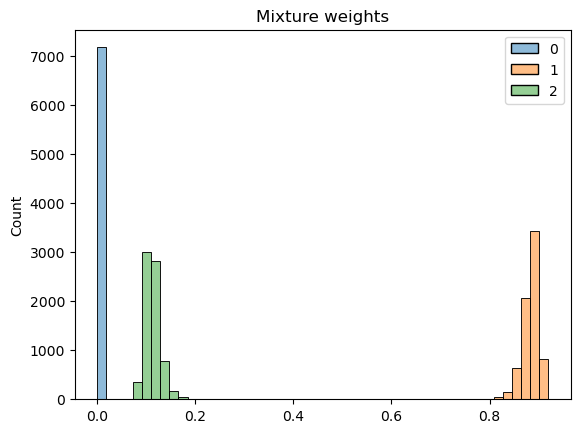

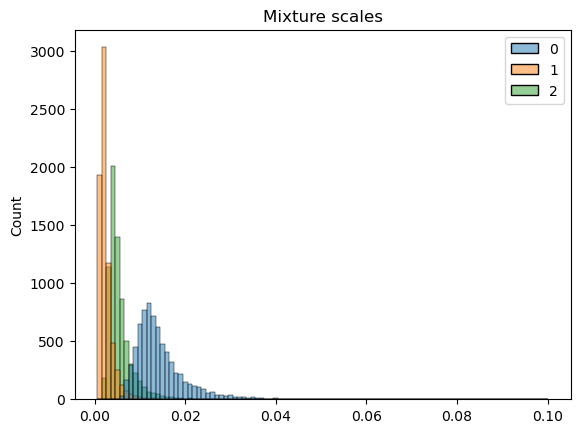

In [132]:
val_weights, val_means, val_scales = (p.numpy() for p in get_predicted_parameters(model, val_loader))
ax = sns.histplot(val_weights, bins=50)
ax.set_title("Mixture weights")
plt.show()

# ax = sns.histplot(val_means, bins=50)
# ax.set_title("Mixture means")
# plt.show()

ax = sns.histplot(val_scales, bins=100)
ax.set_title("Mixture scales")
plt.show()

### Transfer Learning

In [12]:
class MDNBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_layers=2, dropout=0):
        super().__init__()

        hidden_layer_list = []
        for i in range(hidden_layers):
            hidden_layer_list.append((f"linear{i}", nn.Linear(hidden_dim, hidden_dim)))
            hidden_layer_list.append((f"relu{i}", nn.ReLU()))
            hidden_layer_list.append((f"dropout{i}", nn.Dropout(dropout)))


        self.net = nn.Sequential(OrderedDict([
            ("input", nn.Linear(input_dim, hidden_dim)),
            ("relu_input", nn.ReLU()),
            ("dropout_input", nn.Dropout(dropout))] + hidden_layer_list
        ))

        self.hidden_dim = hidden_dim

    def forward(self, x):
        return self.net(x)
    
class MDNPretrain(nn.Module):
    def __init__(self, backbone,):
        super().__init__()
        self.backbone = backbone
        hidden_dim = backbone.hidden_dim

        self.vol_5_prediction = nn.Linear(hidden_dim, 1)
        self.vol_15_prediction = nn.Linear(hidden_dim, 1)
        self.vol_30_prediction = nn.Linear(hidden_dim, 1)
        self.mean_abs_30_prediction = nn.Linear(hidden_dim, 1)
        self.move_direction = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x_backbone = self.backbone(x)

        return (self.vol_5_prediction(x_backbone), self.vol_15_prediction(x_backbone),
                self.vol_30_prediction(x_backbone), self.mean_abs_30_prediction(x_backbone),
                self.move_direction(x_backbone))

        
        

class MDNFinalLayer(nn.Module):
    def __init__(self, backbone, n_components=3, mean_zero=True):
        super().__init__()
        self.backbone = backbone
        self.hidden_dim = backbone.hidden_dim

        self.mixture_weights = nn.Linear(self.hidden_dim, n_components)
        if not mean_zero:
            self.means = nn.Linear(self.hidden_dim, n_components)
        else:
            self.means = None
        self.scales = nn.Linear(self.hidden_dim, n_components)

        self.n_components = n_components

    def forward(self, x):
        out = self.backbone(x)

        mixture_weights = self.mixture_weights(out)

        if self.means is not None:
            uncentered_means = self.means(out)
            means = uncentered_means - torch.mean(uncentered_means)
        else:
            means = torch.zeros(out.shape[0], self.n_components, device=out.device)

        scales = F.softplus(self.scales(out)) + 1e-6

        return mixture_weights, means, scales

In [13]:
NUM_FEATURES = [
    "past_1m_ret",
    "past_5m_ret",
    "past_30m_ret",
    "past_60m_ret",
    "past_120m_ret",
    "past_1m_sq_ret",
    "past_5m_sq_ret",
    "past_30m_sq_ret",
    "past_60m_sq_ret",
    "past_120m_sq_ret",
    "past_1440m_vol",
    "past_10080m_vol",
    "past_43200m_vol",
    "past_50m_span_ewm_vol",
    "past_50m_vol_pct_change",
    "past_30m_quote_volume",
    "past_30m_trades",
    "quote_volume_pct_change",
    "is_us_trading_day",
    "is_eu_trading_day",
    "is_uk_trading_day",
    "is_jp_trading_day",
    "is_cn_trading_day",
    "is_hk_trading_day",
    "is_us_dst",
    "is_eu_dst",
    "gbt_future_30m_mean_sq_ret_pred"
]

CAT_FEATURES = ["time_of_day", "event_code"]

TARGET_COL = ["future_5m_mean_sq_ret", "future_15m_mean_sq_ret", 
              "future_30m_mean_sq_ret", "future_30m_mean_abs_ret",
              "future_30m_neutral_up_down"]


df = add_future_mean_sq_returns(df, [30])
df = add_future_sq_returns(df, [30])

df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna()
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()

# Make numerical feature tensors
X_train_num = df_train[NUM_FEATURES].to_numpy(dtype=np.float32)
X_val_num = df_val[NUM_FEATURES].to_numpy(dtype=np.float32)
y_train_pre = df_train[TARGET_COL].to_numpy(dtype=np.float32)
y_val_pre = df_val[TARGET_COL].to_numpy(dtype=np.float32)

# Scale features, train scaler on train set
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num)

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)

# Make categorical feature tensors
X_train_cat = df_train[CAT_FEATURES]
X_val_cat = df_val[CAT_FEATURES]

# Encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
X_train_cat = encoder.fit_transform(X_train_cat)
X_val_cat = encoder.transform(X_val_cat)

X_train_cat = torch.tensor(X_train_cat, dtype=torch.float32)
X_val_cat = torch.tensor(X_val_cat, dtype=torch.float32)

X_train = torch.cat([X_train_num, X_train_cat], dim=1)
X_val = torch.cat([X_val_num, X_val_cat], dim=1)

y_train_pre = torch.tensor(y_train_pre, dtype=torch.float32)
y_val_pre = torch.tensor(y_val_pre, dtype=torch.float32)

In [14]:
# def compute_pretrain_loss_from_output(vol_true, vol_pred, loss_fn):
#     mse_vol = loss_fn(vol_pred, vol_true)

#     # Return weighted average; std of "vol" is about 4x bigger than mean 1m squared return
#     return mse_vol

# def compute_pretrain_loss(model, data_loader, loss_fn):
#     model.eval() 
#     size = 0
#     loss_sum = 0
#     with torch.no_grad():
#         for (X, y) in data_loader:
#             X, y = X.to(device), y.to(device)
#             vol_5, vol_30, abs_30 = model(X)

#             loss = compute_pretrain_loss_from_output(y, vol, loss_fn)
#             loss_sum += loss * X.size(0)
#             size += X.size(0)

#     return loss_sum / size
    


# # Function to train MDN
# def pretrain_mdn(model, data_loader, optimizer, loss_fn):
#     model = model.to(device)

#     model.train()
#     losses = []


#     for _, (X, y) in enumerate(data_loader):
#         X, y = X.to(device), y.to(device)

#         optimizer.zero_grad()
#         vol, sq_ret = model(X)

#         loss = compute_pretrain_loss_from_output(y, vol, loss_fn)

#         losses.append(loss.item())

#         loss.backward()
#         optimizer.step()
    
#     return np.mean(losses)


def compute_pretrain_loss_from_output(
    vol_5_true,
    vol_5_pred,
    vol_15_true,
    vol_15_pred,
    vol_30_true,
    vol_30_pred,
    abs_30_true,
    abs_30_pred,
    direction_true,
    direction_pred,
    loss_fn,
    lambda_vol_5=1.0,
    lambda_vol_15=1.0,
    lambda_vol_30=1.0,
    lambda_abs_30=1e-4,
    lambda_direction=3e-3,
):
    loss_vol_5 = loss_fn(vol_5_pred, vol_5_true)
    loss_vol_15 = loss_fn(vol_15_pred, vol_15_true)
    loss_vol_30 = loss_fn(vol_30_pred, vol_30_true)
    loss_abs_30 = loss_fn(abs_30_pred, abs_30_true)

    loss_direction = F.cross_entropy(direction_pred, direction_true)

    return (
        lambda_vol_5 * loss_vol_5
        + lambda_vol_15 * loss_vol_15
        + lambda_vol_30 * loss_vol_30
        + lambda_abs_30 * loss_abs_30
        + lambda_direction * loss_direction
    )


def compute_pretrain_loss(model, data_loader, loss_fn):
    model.eval() 
    size = 0
    loss_sum = 0
    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)

            vol_5_pred, vol_15_pred, vol_30_pred, abs_30_pred, direction_pred = model(X)

            loss = compute_pretrain_loss_from_output(
                y[:, 0:1], vol_5_pred,
                y[:, 1:2], vol_15_pred,
                y[:, 2:3], vol_30_pred,
                y[:, 3:4], abs_30_pred,
                y[:, 4].long(), direction_pred,
                loss_fn,
            )

            loss_sum += loss.item() * X.size(0)
            size += X.size(0)

    return loss_sum / size
    


# Function to train MDN
def pretrain_mdn(model, data_loader, optimizer, loss_fn):
    model = model.to(device)

    model.train()
    losses = []

    for _, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        vol_5_pred, vol_15_pred, vol_30_pred, abs_30_pred, direction_pred = model(X)

        loss = compute_pretrain_loss_from_output(
            y[:, 0:1], vol_5_pred,
            y[:, 1:2], vol_15_pred,
            y[:, 2:3], vol_30_pred,
            y[:, 3:4], abs_30_pred,
            y[:, 4].long(), direction_pred,
            loss_fn,
        )

        losses.append(loss.item())

        loss.backward()
        optimizer.step()
    
    return np.mean(losses)


def compute_pretrain_loss_components(model, data_loader, loss_fn):
    model.eval()
    size = 0

    loss_vol_5_sum = 0
    loss_vol_15_sum = 0
    loss_vol_30_sum = 0
    loss_abs_30_sum = 0
    loss_direction_sum = 0

    with torch.no_grad():
        for (X, y) in data_loader:
            X, y = X.to(device), y.to(device)

            vol_5_pred, vol_15_pred, vol_30_pred, abs_30_pred, direction_pred = model(X)

            loss_vol_5 = loss_fn(vol_5_pred, y[:, 0:1])
            loss_vol_15 = loss_fn(vol_15_pred, y[:, 1:2])
            loss_vol_30 = loss_fn(vol_30_pred, y[:, 2:3])
            loss_abs_30 = loss_fn(abs_30_pred, y[:, 3:4])

            loss_direction = F.cross_entropy(direction_pred, y[:, 4].long())

            loss_vol_5_sum += loss_vol_5.item() * X.size(0)
            loss_vol_15_sum += loss_vol_15.item() * X.size(0)
            loss_vol_30_sum += loss_vol_30.item() * X.size(0)
            loss_abs_30_sum += loss_abs_30.item() * X.size(0)
            loss_direction_sum += loss_direction.item() * X.size(0)

            size += X.size(0)

    return (
        loss_vol_5_sum / size,
        loss_vol_15_sum / size,
        loss_vol_30_sum / size,
        loss_abs_30_sum / size,
        loss_direction_sum / size,
    )

In [20]:
train_data_pre = TensorDataset(X_train, y_train_pre)
val_data_pre = TensorDataset(X_val, y_val_pre)

train_loader_pre = DataLoader(train_data_pre, batch_size=128, shuffle=True)
val_loader_pre = DataLoader(val_data_pre, batch_size=128, shuffle=False)

backbone = MDNBackbone(
    input_dim=X_train.shape[1],
    hidden_dim=32,
    hidden_layers=3,
)

pretrain_model = MDNPretrain(
    backbone=backbone
)

optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=1e-4, weight_decay=5e-5)
loss_fn = F.huber_loss
epochs = 1000
results = []
best_val_loss = np.inf
last_improvement = 0
best_state_dict_pretrain = None

for t in range(epochs):
    epoch_loss = pretrain_mdn(pretrain_model, train_loader_pre, optimizer, loss_fn)
    epoch_val_loss = compute_pretrain_loss(pretrain_model, val_loader_pre, loss_fn)
    epoch_train_loss = compute_pretrain_loss(pretrain_model, train_loader_pre, loss_fn)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        last_improvement = t
        best_state_dict_pretrain = copy.deepcopy(pretrain_model.state_dict())

    if t % 20 == 19:
        print(f"Epoch {t+1}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss}, training loss: {epoch_train_loss}, val loss: {epoch_val_loss}\n")

        vol5_l, vol15_l, vol30_l, abs30_l, direction_l = compute_pretrain_loss_components(
            pretrain_model, val_loader_pre, loss_fn
        )
        print(f"vol5: {vol5_l}, vol15: {vol15_l}, vol30: {vol30_l}, abs30: {abs30_l}, direction: {direction_l}\n")

    results.append([epoch_loss, epoch_train_loss, epoch_val_loss])
    
    if t - last_improvement >= 100:
        print(f"Best val loss: {best_val_loss}")
        break

KeyboardInterrupt: 

In [19]:
if best_state_dict_pretrain is not None:
    pretrain_model.load_state_dict(best_state_dict_pretrain)

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

transfer_model = MDNFinalLayer(backbone, n_components=5, mean_zero=True)

if transfer_model.means is not None:
    torch.nn.init.zeros_(transfer_model.means.weight)
    torch.nn.init.zeros_(transfer_model.means.bias)
    
# freeze backbone if I want
for param in transfer_model.backbone.parameters():
    param.requires_grad = True

if transfer_model.means is not None:
    optimizer = torch.optim.Adam(
        [
            {"params": transfer_model.backbone.parameters(), "lr": 4e-5},
            {"params": transfer_model.mixture_weights.parameters(), "lr": 6e-5},
            {"params": transfer_model.scales.parameters(), "lr": 6e-5},
            {"params": transfer_model.means.parameters(), "lr": 4e-6},
        ],
    )

else:
        optimizer = torch.optim.Adam(
        [
            {"params": transfer_model.backbone.parameters(), "lr": 4e-5},
            {"params": transfer_model.mixture_weights.parameters(), "lr": 6e-5},
            {"params": transfer_model.scales.parameters(), "lr": 6e-5},
        ],
    )

epochs = 500
results = []
best_val_nll = np.inf
last_improvement = 0
best_state_dict = None

for t in range(epochs):

    epoch_loss = train_mdn(transfer_model, train_loader, optimizer)
    epoch_val_nll = compute_nll(transfer_model, val_loader)
    epoch_train_nll = compute_nll(transfer_model, train_loader)
    epoch_val_crps = compute_crps(transfer_model, val_loader)

    if epoch_val_nll < best_val_nll:
        best_val_nll = epoch_val_nll
        last_improvement = t
        best_state_dict = copy.deepcopy(transfer_model.state_dict())

    if t % 20 == 19:
        print(f"Epoch {t+1}/{epochs}\n-------------------------------")
        print(f"Loss: {epoch_loss:.2f}, training nll: {epoch_train_nll}, val nll: {epoch_val_nll}, val crps: {epoch_val_crps}\n")
    results.append([epoch_loss, epoch_train_nll, epoch_val_nll, epoch_val_crps])
    
    if t - last_improvement >= 100:
        print(f"Best val loss: {best_val_nll}")
        break



if best_state_dict is not None:
    transfer_model.load_state_dict(best_state_dict)

NameError: name 'best_state_dict_pretrain' is not defined

In [18]:
torch.save(transfer_model.state_dict(), "transfer_model_4-569.pt")

# Compare Models

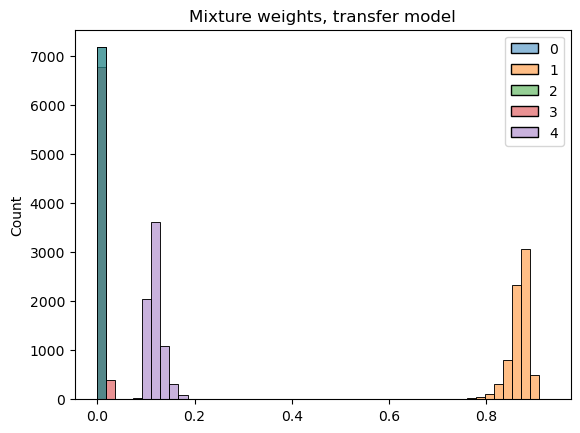

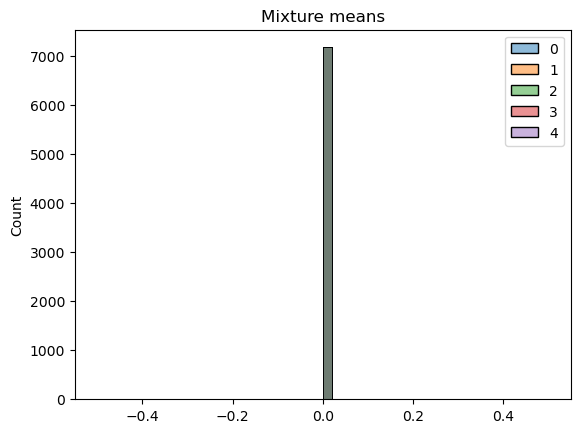

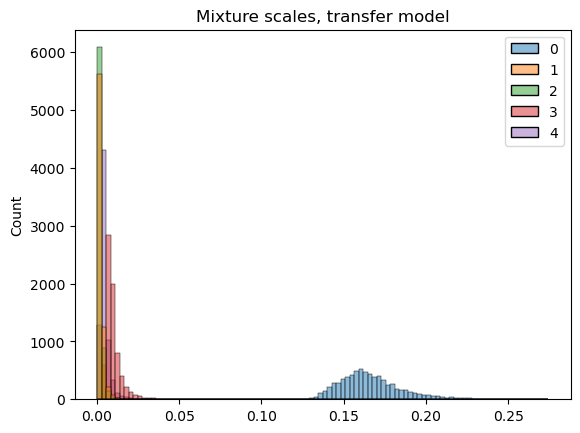

In [102]:
val_weights, val_means, val_scales = (p.numpy() for p in get_predicted_parameters(transfer_model, val_loader))
ax = sns.histplot(val_weights, bins=50)
ax.set_title("Mixture weights, transfer model")
plt.show()

ax = sns.histplot(val_means, bins=50)
ax.set_title("Mixture means")
plt.show()

ax = sns.histplot(val_scales, bins=100)
ax.set_title("Mixture scales, transfer model")
plt.show()

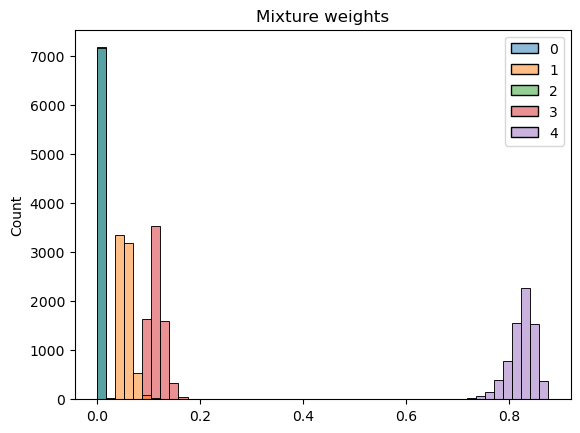

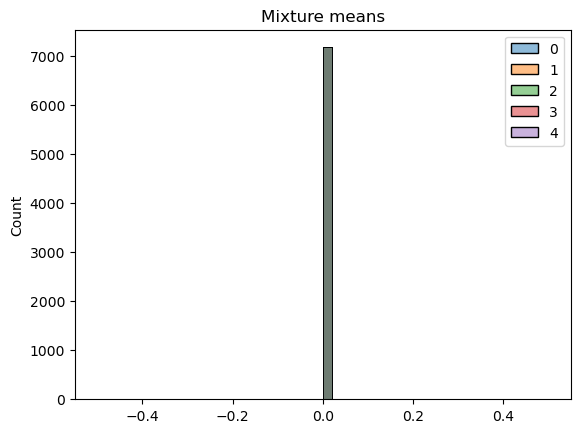

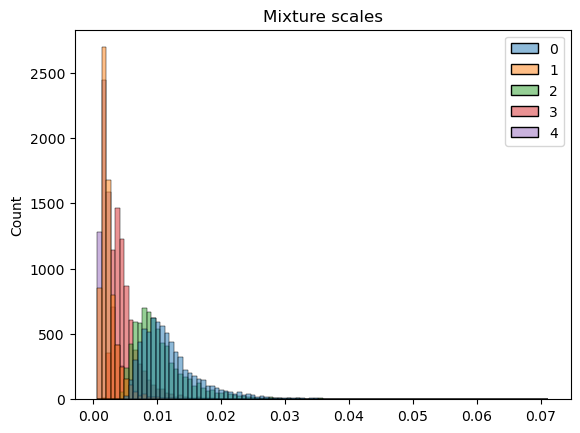

In [99]:
val_weights, val_means, val_scales = (p.numpy() for p in get_predicted_parameters(model, val_loader))
ax = sns.histplot(val_weights, bins=50)
ax.set_title("Mixture weights")
plt.show()

ax = sns.histplot(val_means, bins=50)
ax.set_title("Mixture means")
plt.show()

ax = sns.histplot(val_scales, bins=100)
ax.set_title("Mixture scales")
plt.show()

In [21]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import norm


import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import norm


def plot_mdn_models_typical(X, models, device="cpu", left=-0.05, right=0.05, n_grid=1000):
    """
    Plot MDN densities for multiple models using:
        - medoid datapoint
        - mean feature vector

    models: {"name": model}
    """

    if isinstance(X, np.ndarray):
        X = torch.tensor(X, dtype=torch.float32)

    X = X.to(device)

    # mean input
    x_mean = X.mean(dim=0, keepdim=True)

    # medoid datapoint
    distances = torch.norm(X - x_mean, dim=1)
    medoid_idx = torch.argmin(distances)
    x_medoid = X[medoid_idx:medoid_idx+1]

    grid = np.linspace(left, right, n_grid)

    plt.figure(figsize=(8,5))

    for name, model in models.items():

        model.eval()

        def compute_pdf(x):
            with torch.no_grad():
                w, mu, sigma = model(x)

                w = F.softmax(w, dim=1).cpu().numpy()[0]
                mu = mu.cpu().numpy()[0]
                sigma = sigma.cpu().numpy()[0]

            pdf = np.zeros_like(grid)
            for k in range(len(w)):
                pdf += w[k] * norm.pdf(grid, mu[k], sigma[k])

            return pdf

        pdf_medoid = compute_pdf(x_medoid)
        pdf_mean = compute_pdf(x_mean)

        plt.plot(grid, pdf_medoid, label=f"{name} (medoid)")
        plt.plot(grid, pdf_mean, linestyle="--", label=f"{name} (mean)")

    plt.axvline(0, linestyle="--", alpha=0.3)
    plt.xlim(left, right)
    plt.xlabel("return")
    plt.ylabel("density")
    plt.title("Predicted return densities (medoid vs mean input)")
    plt.legend()
    plt.show()

    return medoid_idx

###

In [120]:
plot_mdn_models_typical(X_val, {"original": model, "transfer": transfer_model})

NameError: name 'plot_mdn_models_typical' is not defined

In [121]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


def compute_pit(model, loader, device="cpu"):

    model.eval()
    pits = []

    with torch.no_grad():
        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            w, mu, sigma = model(X)

            w = F.softmax(w, dim=1).cpu().numpy()
            mu = mu.cpu().numpy()
            sigma = sigma.cpu().numpy()
            y = y.cpu().numpy()

            for i in range(len(y)):

                cdf = 0
                for k in range(w.shape[1]):
                    cdf += w[i,k] * norm.cdf(y[i], mu[i,k], sigma[i,k])

                pits.append(cdf)

    return np.array(pits)

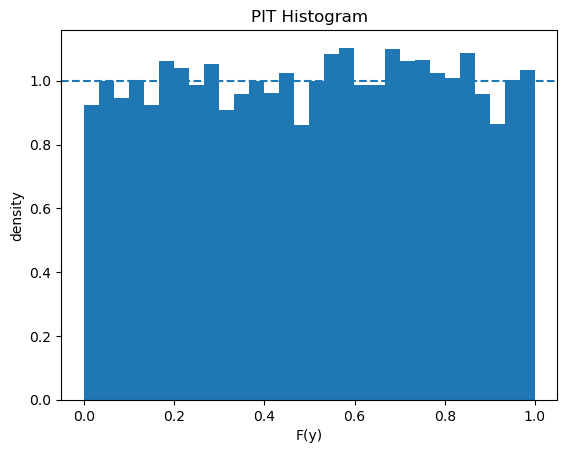

In [122]:
pits = compute_pit(model, val_loader)

plt.hist(pits, bins=30, density=True)
plt.axhline(1, linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("F(y)")
plt.ylabel("density")
plt.show()

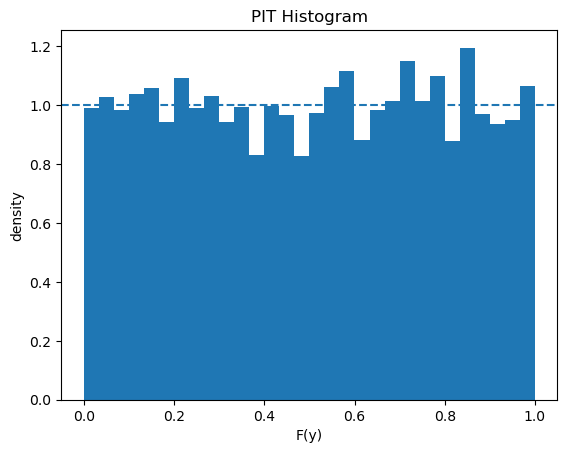

In [28]:
transfer_model = MDNFinalLayer(backbone, n_components=5, mean_zero=False)
transfer_model.load_state_dict(torch.load("transfer_model_4-567.pt", map_location="cpu"))

pits = compute_pit(transfer_model, val_loader)

plt.hist(pits, bins=30, density=True)
plt.axhline(1, linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("F(y)")
plt.ylabel("density")
plt.show()

In [29]:
def plot_mdn_vs_gbt_vol_medoid(X, models, df, gbt_col, X_index,
                               left=-0.05, right=0.05, n_grid=1000):

    import numpy as np
    import torch
    import torch.nn.functional as F
    import matplotlib.pyplot as plt
    from scipy.stats import norm

    if isinstance(X, np.ndarray):
        X = torch.tensor(X, dtype=torch.float32)

    # align GBT predictions with X rows
    gbt_pred = df.loc[X_index, gbt_col].values

    # medoid
    x_mean = X.mean(dim=0, keepdim=True)
    distances = torch.norm(X - x_mean, dim=1)
    medoid_idx = int(torch.argmin(distances))

    x_medoid = X[medoid_idx:medoid_idx+1]

    grid = np.linspace(left, right, n_grid)

    def mdn_pdf(model):

        model.eval()

        with torch.no_grad():
            w, mu, sigma = model(x_medoid)

        w = F.softmax(w, dim=1).cpu().numpy()[0]
        mu = mu.cpu().numpy()[0]
        sigma = sigma.cpu().numpy()[0]

        pdf = np.zeros_like(grid)

        for k in range(len(w)):
            pdf += w[k] * norm.pdf(grid, mu[k], sigma[k])

        return pdf

    plt.figure(figsize=(8,5))

    for name, model in models.items():
        pdf = mdn_pdf(model)
        plt.plot(grid, pdf, label=name)

    # GBT implied normal
    sigma = np.sqrt(gbt_pred[medoid_idx] * 30)

    plt.plot(grid,
             norm.pdf(grid, 0, sigma),
             color="black",
             linewidth=2,
             label="GBT normal")

    plt.axvline(0, color="gray", linestyle=":")
    plt.xlim(left, right)
    plt.xlabel("return")
    plt.ylabel("density")
    plt.title("MDN vs GBT-implied Normal (medoid datapoint)")
    plt.legend()
    plt.show()

    return medoid_idx

In [123]:
plot_mdn_vs_gbt_vol_medoid(
    X_val,
    {"original": model, "transfer": transfer_model},
    df_val,
    "gbt_future_30m_mean_sq_ret_pred",
    df_val.index
)

NameError: name 'plot_mdn_vs_gbt_vol_medoid' is not defined

### Trading Simulation

In [124]:
def price_call_mixture(strike_return, mixture_weights, means, scales):
    z = (means - strike_return) / scales
    individual_prices = (means - strike_return) * stats.norm.cdf(z) + scales * stats.norm.pdf(z)
    return torch.sum(mixture_weights * individual_prices, dim=1)

def simulate_call_trades_mdn(strike_return, model_one, model_two, X, y):
    model_one.eval() 
    model_two.eval()
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_weights, means, scales = model_one(X)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        prices_one = price_call_mixture(strike_return, mixture_probs, means, scales)

        mixture_weights, means, scales = model_two(X)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        prices_two = price_call_mixture(strike_return, mixture_probs, means, scales)

        trade_price = 0.5 * (prices_one + prices_two)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        direction = torch.where(prices_one < prices_two, -1, 1)

        return direction * (payoff - trade_price)
    

def price_call_normal(sigma: float, strike_return: float, mu: float = 0.0):
    z = (mu - strike_return) / sigma
    return np.where(sigma > 0, (mu - strike_return) * stats.norm.cdf(z) + sigma * stats.norm.pdf(z), max(mu - strike_return, 0.0))


def simulate_call_trades_mdn_vs_gbt(strike_return, model, X, y, df):
    pnls = []

    model.eval() 
    with torch.no_grad():
        X, y = X.to(device), y.to(device)
        
        mixture_weights, means, scales = model(X)
        mixture_probs = F.softmax(mixture_weights, dim=1)
        prices_mdn = price_call_mixture(strike_return, mixture_probs, means, scales)

        gbt_sigma = np.sqrt(df["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)
        prices_gbt = torch.tensor(price_call_normal(gbt_sigma, strike_return))

        trade_price = 0.5 * (prices_mdn + prices_gbt)

        payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

        direction = torch.where(prices_mdn < prices_gbt, -1, 1)

        pnls.append(direction * (payoff - trade_price))


    return torch.cat(pnls).numpy()

# def simulate_call_trades_mdn_vs_gbt(strike_return, model, model_two, data_loader, df):
#     pnls = []

#     model_one.eval() 
#     model_two.eval()
#     with torch.no_grad():
#         for (X, y) in data_loader:
#             X, y = X.to(device), y.to(device)
            
#             mixture_weights, means, scales = model_one(X)
#             mixture_probs = F.softmax(mixture_weights, dim=1)
#             prices_one = price_call_mixture(strike_return, mixture_probs, means, scales)

#             mixture_weights, means, scales = model_two(X)
#             mixture_probs = F.softmax(mixture_weights, dim=1)
#             prices_two = price_call_mixture(strike_return, mixture_probs, means, scales)

#             trade_price = 0.5 * (prices_one + prices_two)

#             payoff = torch.maximum(y - strike_return, torch.zeros_like(y))

#             direction = torch.where(prices_one < prices_two, -1, 1)

#             pnls.append(direction * (payoff - trade_price))


#     return torch.cat(pnls).numpy()



<Axes: >

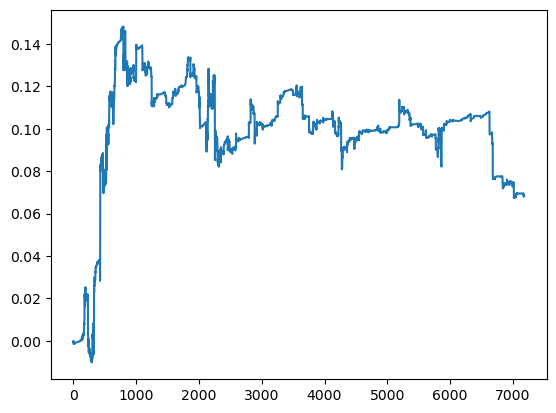

In [126]:
transfer_model_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=False)
transfer_model_ret.load_state_dict(torch.load("transfer_model_4-567.pt", map_location="cpu"))

transfer_model_no_ret = MDNFinalLayer(backbone, n_components=5, mean_zero=True)
transfer_model_no_ret.load_state_dict(torch.load("transfer_model_4-569.pt", map_location="cpu"))

pnls = simulate_call_trades_mdn(0.005, transfer_model_no_ret, model, X_val, y_val)
sns.lineplot(np.cumsum(pnls))

<Axes: >

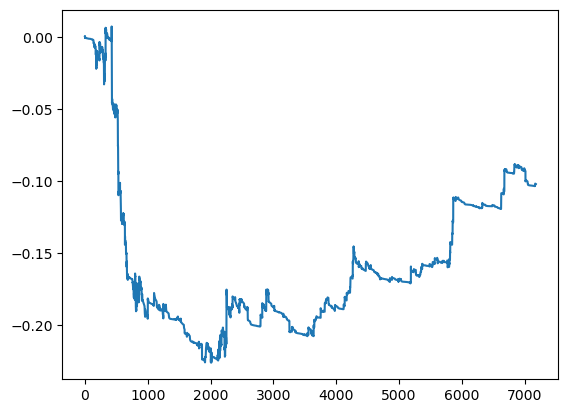

In [131]:
pnls = simulate_call_trades_mdn_vs_gbt(0.005, model, X_val, y_val, df_val)
sns.lineplot(np.cumsum(pnls))

<Axes: >

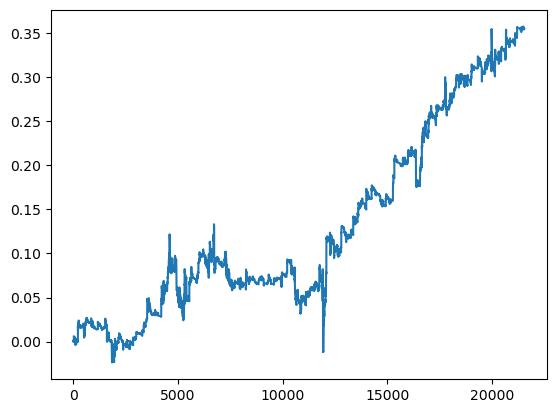

In [129]:
pnls = simulate_call_trades_mdn_vs_gbt(0.005, transfer_model_no_ret, X_train, y_train, df_train)
sns.lineplot(np.cumsum(pnls))

<Axes: >

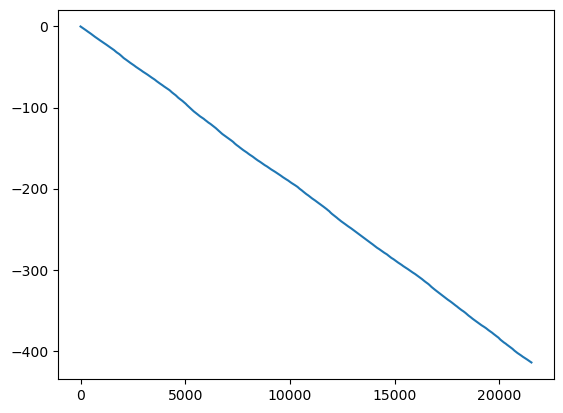

In [98]:
pnls = simulate_call_trades_mdn_vs_gbt(0.005, transfer_model_ret, X_train, y_train, df_train)
sns.lineplot(np.cumsum(pnls))